# Probability, dependence, and conditioning
**DS-UA 201 · Fall 2026**  
**Center for Data Science, New York University**

**TA: Xiang Gao**

September 18, 2026

[Open in Colab](https://colab.research.google.com/github/xgao0o/DS-UA_201-Causal-Inference-Fall-2026/blob/main/labs/2-Probability.ipynb) (available after publication to the repository).

All datasets in this notebook are **synthetic** and are used only for teaching. They are not empirical findings about people, health, or behavior.


## Goals and roadmap
By the end of this lab, you should be able to:

- compute joint, marginal, and conditional probabilities;
- distinguish population moments from finite-sample summaries;
- calculate and interpret covariance and correlation;
- use conditional expectation, conditional variance, and the law of iterated expectations;
- explain why independence implies zero covariance but zero covariance need not imply independence;
- define the ATE, ATT, and ATU in the all-causes model; and
- connect independence and conditional independence assumptions to causal identification.


## Setup
Run cells from top to bottom with **Shift+Enter**. Restart the kernel and run all cells to reproduce the saved results. The notebook uses only NumPy, pandas, and Matplotlib and downloads no external data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

rng = np.random.default_rng(201)

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## 1. Joint, marginal, and conditional probability

### A synthetic height example
Let $H$ denote height and $G$ a group label. Their **joint distribution** describes probabilities involving both variables. For discrete values,

$$p_{H,G}(h,g)=P(H=h,G=g).$$

Height is continuous, so an exact point has probability zero in a continuous model. We can instead study events such as $H>180$ or bin height into intervals.

The next cell creates a self-contained synthetic dataset. To keep the example simple, the simulated `Sex` variable has two categories.


In [2]:
n_people = 1_000
sex = rng.choice(["Female", "Male"], size=n_people, p=[0.52, 0.48])
mean_height = np.where(sex == "Male", 176, 163)
height = rng.normal(mean_height, 7)

height_data = pd.DataFrame({"Height": height, "Sex": sex})
height_data.head()


,Height,Sex
0,177.446969,Male
1,165.493845,Male
2,156.783059,Female
3,157.775068,Male
4,175.032174,Male


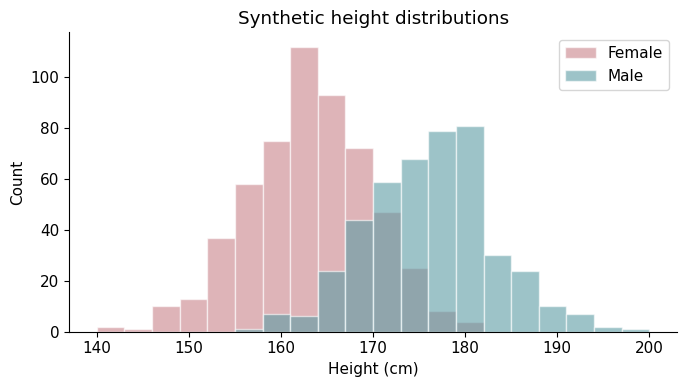

In [3]:
fig, ax = plt.subplots()
for label, color in [("Female", "#c98389"), ("Male", "#5c9ba4")]:
    values = height_data.loc[height_data["Sex"] == label, "Height"]
    ax.hist(values, bins=np.arange(140, 202, 3), alpha=0.60, label=label,
            color=color, edgecolor="white")
ax.set(title="Synthetic height distributions", xlabel="Height (cm)", ylabel="Count")
ax.legend()
fig.tight_layout()
plt.show()


### Joint probability
For a finite dataset, an empirical probability is a sample proportion. For example,

$$\widehat{P}(H>180,G=\text{Male})
=\frac{\#\{i:H_i>180,,G_i=\text{Male}\}}{N}.$$

The hat reminds us that this is an estimate from a realized sample, not the population probability itself.


In [4]:
height_cutoff = 180
is_tall = height_data["Height"] > height_cutoff
is_male = height_data["Sex"] == "Male"

p_tall_and_male = (is_tall & is_male).mean()
print(f"Estimated P(H > {height_cutoff}, G = Male): {p_tall_and_male:.3f}")


Estimated P(H > 180, G = Male): 0.134


### Marginal probability
A **marginal distribution** describes one variable after summing or integrating over the other. Because `Female` and `Male` partition this synthetic sample,

$$P(H>180)=\sum_g P(H>180,G=g).$$


In [5]:
p_tall_and_female = (is_tall & ~is_male).mean()
p_tall_direct = is_tall.mean()
p_tall_by_marginalizing = p_tall_and_male + p_tall_and_female

print(f"P(H > {height_cutoff}, G = Male):   {p_tall_and_male:.3f}")
print(f"P(H > {height_cutoff}, G = Female): {p_tall_and_female:.3f}")
print(f"P(H > {height_cutoff}) directly:    {p_tall_direct:.3f}")
print(f"P(H > {height_cutoff}) by summing:  {p_tall_by_marginalizing:.3f}")

assert np.isclose(p_tall_direct, p_tall_by_marginalizing)


P(H > 180, G = Male):   0.134
P(H > 180, G = Female): 0.002
P(H > 180) directly:    0.136
P(H > 180) by summing:  0.136


We can bin height to display an empirical joint probability mass function. Each interior cell is the fraction of the entire sample in that height bin and group; all interior cells together sum to 1.


In [6]:
height_data["Height_bin"] = pd.cut(
    height_data["Height"],
    bins=[-np.inf, 160, 170, 180, np.inf],
    labels=["≤160", "(160, 170]", "(170, 180]", ">180"],
)

joint_pmf = pd.crosstab(
    height_data["Height_bin"], height_data["Sex"], normalize=True, margins=True
)
display(joint_pmf.round(3))


Sex,Female,Male,All
Height_bin,,,
≤160,0.170,0.008,0.178
"(160, 170]",0.303,0.074,0.377
"(170, 180]",0.082,0.227,0.309
>180,0.002,0.134,0.136
All,0.557,0.443,1.000


### Conditional probability
Conditioning changes the reference group. Among simulated males,

$$P(H>180\mid G=\text{Male})
=\frac{P(H>180,G=\text{Male})}{P(G=\text{Male})},$$

provided $P(G=\text{Male})>0$. The denominator is now the number of simulated males rather than the total sample size.


In [8]:
p_male = is_male.mean()
p_tall_given_male_ratio = p_tall_and_male / p_male
p_tall_given_male_direct = is_tall[is_male].mean()

print(f"Joint P(H > {height_cutoff}, G = Male): {p_tall_and_male:.3f}")
print(f"Marginal P(G = Male):                  {p_male:.3f}")
print(f"Conditional P(H > {height_cutoff} | G = Male): {p_tall_given_male_ratio:.3f}")

assert np.isclose(p_tall_given_male_ratio, p_tall_given_male_direct)


Joint P(H > 180, G = Male): 0.134
Marginal P(G = Male):                  0.443
Conditional P(H > 180 | G = Male): 0.302


### Exercise 1
Estimate $P(H>170\mid G=\text{Female})$. Which rows belong in the denominator?

<details><summary>Answer</summary>

The denominator contains all rows labeled `Female`; the numerator contains the subset of those rows with height above 170 cm.

```python
is_female = height_data["Sex"] == "Female"
p = (height_data.loc[is_female, "Height"] > 170).mean()
print(f"P(H > 170 | G = Female) = {p:.3f}")
```

Equivalently, divide `((Height > 170) & is_female).mean()` by `is_female.mean()`.

</details>


## 2. Variance, covariance, and correlation

### Population quantities and sample estimates
For random variables $X$ and $Y$ with finite second moments,

$$\operatorname{Var}(X)=\mathbb{E}[(X-\mathbb{E}[X])^2],$$

$$\operatorname{Cov}(X,Y)
=\mathbb{E}[(X-\mathbb{E}[X])(Y-\mathbb{E}[Y])]
=\mathbb{E}[XY]-\mathbb{E}[X]\mathbb{E}[Y].$$

These are **population parameters**. Given $N$ observations, a common sample covariance estimator is

$$\widehat{\operatorname{Cov}}(X,Y)
=\frac{1}{N-1}\sum_{i=1}^{N}(x_i-\bar{x})(y_i-\bar{y}).$$

Other properties

$$Cov(X, Y) = Cov(Y, X)$$

$$Cov(X, a) = 0$$

$$Cov(X+Y, Z) = Cov(X, Z) + Cov(Y, Z)$$

$$Cov(a+bX, Y) = bCov(X, Y)$$

NumPy uses this $N-1$ convention when we call `np.cov`; use `np.var(..., ddof=1)` for the matching sample variance. Keeping the convention consistent matters when checking identities numerically.


In [11]:
x = rng.normal(size=1_000)
y = 2 * x + rng.normal(scale=0.75, size=1_000)

sample_covariance = np.cov(x, y, ddof=1)[0, 1]
sample_correlation = np.corrcoef(x, y)[0, 1]

print(f"Sample covariance:  {sample_covariance:.3f}")
print(f"Sample correlation: {sample_correlation:.3f}")


Sample covariance:  2.031
Sample correlation: 0.937


Covariance records the direction of a linear relationship but depends on the variables' units. Correlation standardizes covariance:

$$\rho_{X,Y}=\frac{\operatorname{Cov}(X,Y)}
{\sqrt{\operatorname{Var}(X)\operatorname{Var}(Y)}}\in[-1,1],$$

when both variances are positive. Correlation is unitless. Values near $1$ or $-1$ indicate strong positive or negative **linear** association; values near zero indicate little linear association, not necessarily no relationship.

Cauchy-Schwarz Inequality:

$$
|\mathbb{E}[X Y]| \leq \sqrt{\mathbb{E}\left[X^2\right] \cdot \mathbb{E}\left[Y^2\right]}
$$


$$
|\operatorname{Cov}(X, Y)|=|\mathbb{E}[(X-\mathbb{E}[X])(Y-\mathbb{E}[Y])]| \leq \sqrt{\mathbb{E}\left[(X-\mathbb{E}[X])^2\right] \cdot \mathbb{E}\left[(Y-\mathbb{E}[Y])^2\right]}
$$

Interpretation:

If $\rho_{X, Y} = 1$, then $Y = aX + b$ with $a > 0$.

If $\rho_{X, Y} = -1$, then $Y = aX + b$ with $a < 0$.

If $\rho_{X, Y} = 0$, then $X$ and $Y$ are independent, $Y$ is constant to $X$.

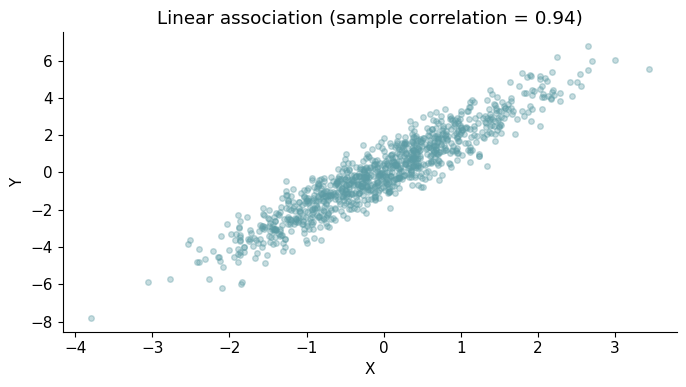

In [10]:
fig, ax = plt.subplots()
ax.scatter(x, y, s=16, alpha=0.35, color="#5c9ba4")
ax.set(title=f"Linear association (sample correlation = {sample_correlation:.2f})",
       xlabel="X", ylabel="Y")
fig.tight_layout()
plt.show()


### Variance of a sum
The covariance term determines whether two sources of variation reinforce or offset each other:

$$\operatorname{Var}(X+Y)
=\operatorname{Var}(X)+\operatorname{Var}(Y)+2\operatorname{Cov}(X,Y).$$

Proof

$$
\begin{aligned}
\operatorname{Var}(X + Y) &= E[(X + Y - E[X + Y])^2] && \text{(Definition of variance)} \\
&= E[(X + Y - (E[X] + E[Y]))^2] && \text{(Substitute } E[X + Y] = E[X] + E[Y]) \\
&= E[(X - E[X] + Y - E[Y])^2] && \text{(Rearrange terms)} \\
&= E[(X - E[X])^2] + E[(Y - E[Y])^2] + 2E[(X - E[X])(Y - E[Y])] && \text{(Expand the square)} \\
&= \operatorname{Var}(X) + \operatorname{Var}(Y) + 2 \operatorname{Cov}(X, Y)
\end{aligned}
$$

More generally,

$$\operatorname{Var}(aX+bY)
=a^2\operatorname{Var}(X)+b^2\operatorname{Var}(Y)+2ab\operatorname{Cov}(X,Y).$$


In [12]:
var_sum_direct = np.var(x + y, ddof=1)
var_sum_identity = (
    np.var(x, ddof=1)
    + np.var(y, ddof=1)
    + 2 * np.cov(x, y, ddof=1)[0, 1]
)

print(f"Var(X + Y), computed directly: {var_sum_direct:.6f}")
print(f"Variance-covariance identity:   {var_sum_identity:.6f}")
assert np.isclose(var_sum_direct, var_sum_identity)


Var(X + Y), computed directly: 9.752365
Variance-covariance identity:   9.752365


### Correlation does not imply causation
Suppose hot weather $W$ increases both ice-cream purchases $I$ and drowning incidents $D$:

$$W\longrightarrow I,\qquad W\longrightarrow D.$$

There is no arrow from ice-cream purchases to drowning in this data-generating process. The two outcomes can nevertheless be associated because they share a cause.


In [13]:
n_days = 5_000
weather_rng = np.random.default_rng(2026)
hot_weather = weather_rng.binomial(1, 0.30, n_days)

p_ice_cream = np.where(hot_weather == 1, 0.80, 0.10)
p_drowning = np.where(hot_weather == 1, 0.20, 0.05)

ice_cream = weather_rng.binomial(1, p_ice_cream)
drowning = weather_rng.binomial(1, p_drowning)

weather_data = pd.DataFrame({
    "Hot_weather": hot_weather,
    "Ice_cream_purchase": ice_cream,
    "Drowning_incident": drowning,
})

marginal_rates = weather_data.groupby("Ice_cream_purchase")["Drowning_incident"].mean()
conditional_rates = weather_data.groupby(
    ["Hot_weather", "Ice_cream_purchase"]
)["Drowning_incident"].agg(["mean", "size"])

print("Marginal drowning rate by ice-cream purchase:")
display(marginal_rates.rename(index={0: "No purchase", 1: "Purchase"}).to_frame("rate"))
print("Drowning rate within weather strata:")
display(conditional_rates)


Marginal drowning rate by ice-cream purchase:


,rate
Ice_cream_purchase,
No purchase,0.068833
Purchase,0.163467


Drowning rate within weather strata:


mean  size
Hot_weather Ice_cream_purchase                
0           0                   0.055483  3082
            1                   0.054321   405
1           0                   0.204620   303
            1                   0.200000  1210

The marginal difference is not the causal effect of buying ice cream. Within each weather stratum, the rates should be similar up to simulation noise because $I$ and $D$ were generated independently after conditioning on $W$. This is a probability statement about the simulation, not evidence about real-world drowning.

### Exercise 2
If $Y=3X-4$ and $\operatorname{Var}(X)>0$, what are $\operatorname{Cov}(X,Y)$ and $\operatorname{Corr}(X,Y)$?

<details><summary>Answer</summary>

Using covariance rules,

$$\operatorname{Cov}(X,3X-4)=3\operatorname{Var}(X).$$

Because $Y$ is an exact increasing affine function of $X$, $\operatorname{Corr}(X,Y)=1$. The constant shift changes neither covariance nor correlation.

</details>


## 3. Conditional moments and iterated expectations

### Conditional expectation
For a discrete variable $Y$,

$$\mathbb{E}[Y\mid X=x]=\sum_y yP(Y=y\mid X=x).$$

For a continuous variable with conditional density $f_{Y\mid X}$,

$$\mathbb{E}[Y\mid X=x]=\int_{-\infty}^{\infty}y f_{Y\mid X}(y\mid x)\,dy.$$

As $x$ changes, the conditional mean may change. Therefore $\mathbb{E}[Y\mid X]$ is itself a random variable: a function of $X$.


In [14]:
conditional_rng = np.random.default_rng(201)
n = 1_000
x_group = conditional_rng.choice([1, 2, 3, 4, 5], size=n,
                                 p=[0.10, 0.15, 0.25, 0.30, 0.20])
epsilon = conditional_rng.normal(0, 1 + 0.25 * x_group, n)
y_outcome = 2 * x_group + epsilon

conditional_data = pd.DataFrame({"X": x_group, "Y": y_outcome})
conditional_summary = conditional_data.groupby("X")["Y"].agg(
    count="size", conditional_mean="mean", conditional_variance=lambda s: s.var(ddof=0)
)
display(conditional_summary.round(3))


,count,conditional_mean,conditional_variance
X,,,
1,99,1.971,1.477
2,155,4.074,2.352
3,284,5.985,2.425
4,286,8.019,3.704
5,176,10.163,4.652


### Law of iterated expectations
The law of iterated expectations (LIE), also called the tower property, states

$$\mathbb{E}[Y]=\mathbb{E}\!\left[\mathbb{E}[Y\mid X]\right].$$

In a sample, the overall mean equals a **weighted** average of group means, where the weights are group proportions. A simple unweighted average of group means is generally different when group sizes differ.


In [ ]:
overall_mean = conditional_data["Y"].mean()
group_weights = conditional_summary["count"] / len(conditional_data)
weighted_group_mean = np.sum(
    group_weights * conditional_summary["conditional_mean"]
)
unweighted_group_mean = conditional_summary["conditional_mean"].mean()

print(f"Overall sample mean:                 {overall_mean:.6f}")
print(f"Weighted mean of conditional means: {weighted_group_mean:.6f}")
print(f"Unweighted mean of group means:     {unweighted_group_mean:.6f}")
assert np.isclose(overall_mean, weighted_group_mean)


Overall sample mean:                 6.608531
Weighted mean of conditional means: 6.608531
Unweighted mean of group means:     6.042386


Proof:

\begin{align}
\mathbb{E}[\mathbb{E}(X \mid Y)] & =\mathbb{E}\left[\sum_{x \in \mathcal{X}} x \cdot \operatorname{Pr}(X=x \mid Y)\right] \\
& =\sum_{y \in \mathcal{Y}}\left[\sum_{x \in \mathcal{X}} x \cdot \operatorname{Pr}(X=x \mid Y=y)\right] \cdot \operatorname{Pr}(Y=y) \\
& =\sum_{x \in \mathcal{X}} \sum_{y \in \mathcal{Y}} x \cdot \operatorname{Pr}(X=x \mid Y=y) \cdot \operatorname{Pr}(Y=y) \\
& =\sum_{x \in \mathcal{X}} \sum_{y \in \mathcal{Y}} x \cdot \operatorname{Pr}(X=x, Y=y) \\
& =\sum_{x \in \mathcal{X}} x \sum_{y \in \mathcal{Y}} \operatorname{Pr}(X=x, Y=y) \\
& =\sum_{x \in \mathcal{X}} x \cdot \operatorname{Pr}(X=x) \\
& =\mathbb{E}(X)
\end{align}

### Conditional variance
The conditional variance is also a function of the conditioning variable:

$$\operatorname{Var}(Y\mid X)
=\mathbb{E}[(Y-\mathbb{E}[Y\mid X])^2\mid X]
=\mathbb{E}[Y^2\mid X]-\mathbb{E}[Y\mid X]^2.$$

For functions $g$ and $h$,

$$\operatorname{Var}(g(X)+h(X)Y\mid X)
=h(X)^2\operatorname{Var}(Y\mid X),$$

because once we condition on $X$, both $g(X)$ and $h(X)$ are fixed.


In [15]:
def population_variance(values):
    # Finite-sample average squared deviation, using denominator N.
    values = np.asarray(values)
    return np.mean((values - values.mean()) ** 2)


check_rows = []
for value, group in conditional_data.groupby("X"):
    y_values = group["Y"].to_numpy()
    direct = population_variance(y_values)
    alternative = np.mean(y_values**2) - np.mean(y_values)**2
    transformed = population_variance(value**2 + (3 * value) * y_values)
    predicted = (3 * value)**2 * direct
    check_rows.append((value, direct, alternative, transformed, predicted))

variance_check = pd.DataFrame(
    check_rows,
    columns=["X", "Var(Y|X)", "E[Y²|X]-E[Y|X]²",
             "Var(X²+3XY|X)", "9X² Var(Y|X)"],
).set_index("X")

display(variance_check.round(3))
assert np.allclose(
    variance_check["Var(X²+3XY|X)"],
    variance_check["9X² Var(Y|X)"],
)


,Var(Y|X),E[Y²|X]-E[Y|X]²,Var(X²+3XY|X),9X² Var(Y|X)
X,,,,
1,1.477,1.477,13.291,13.291
2,2.352,2.352,84.677,84.677
3,2.425,2.425,196.461,196.461
4,3.704,3.704,533.412,533.412
5,4.652,4.652,1046.649,1046.649


### Exercise 3
Why did we weight the conditional means by the group proportions when checking the LIE? When would the unweighted average be correct?

<details><summary>Answer</summary>

The outer expectation averages over the distribution of $X$, so values of $X$ that occur more often must receive more weight. The unweighted average is correct only when the groups have equal probability (or happen to have means that make both averages coincide).

</details>


## 4. Independence and the all-causes model

### Independence
Random variables $X$ and $Y$ are independent, written $X\perp Y$, if for all suitable sets $A$ and $B$,

$$P(X\in A,Y\in B)=P(X\in A)P(Y\in B).$$

Equivalently, when the relevant conditional probabilities or densities are defined, conditioning on one variable does not change the distribution of the other:

$$P(Y\in B\mid X)=P(Y\in B).$$

Consequently,

$$\mathbb{E}[Y\mid X]=\mathbb{E}[Y].$$


In [16]:
dice_rng = np.random.default_rng(2026)
n_rolls = 100_000
die_1 = dice_rng.integers(1, 7, n_rolls)
die_2 = dice_rng.integers(1, 7, n_rolls)

p_both_six = np.mean((die_1 == 6) & (die_2 == 6))
p_product = np.mean(die_1 == 6) * np.mean(die_2 == 6)

print(f"Estimated P(die 1 = 6, die 2 = 6): {p_both_six:.4f}")
print(f"Product of estimated marginals:      {p_product:.4f}")
print(f"Theoretical value 1/36:              {1/36:.4f}")


Estimated P(die 1 = 6, die 2 = 6): 0.0274
Product of estimated marginals:      0.0275
Theoretical value 1/36:              0.0278


### Independence implies zero covariance—but not conversely
If $X\perp Y$ and the relevant moments exist, then

$$\mathbb{E}[XY]=\mathbb{E}[X]\mathbb{E}[Y],$$

so $\operatorname{Cov}(X,Y)=0$. Finite samples from independent variables will usually have covariance close to, but not exactly, zero.

The converse is false. Let $X$ be symmetric around zero and $Y=X^2$. Then $Y$ is completely determined by $X$, so the variables are dependent, but their covariance is zero in the population because positive and negative contributions cancel.


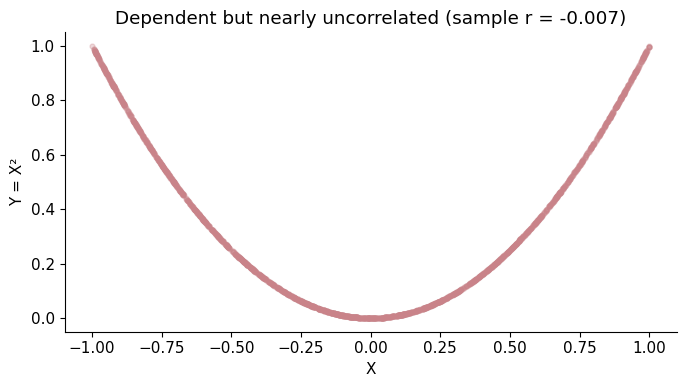

In [17]:
nonlinear_rng = np.random.default_rng(201)
x_nonlinear = nonlinear_rng.uniform(-1, 1, 20_000)
y_nonlinear = x_nonlinear**2
nonlinear_correlation = np.corrcoef(x_nonlinear, y_nonlinear)[0, 1]

fig, ax = plt.subplots()
ax.scatter(x_nonlinear[::10], y_nonlinear[::10], s=12, alpha=0.30,
           color="#c98389")
ax.set(title=f"Dependent but nearly uncorrelated (sample r = {nonlinear_correlation:.3f})",
       xlabel="X", ylabel="Y = X²")
fig.tight_layout()
plt.show()


### Revisiting the all-causes model
The all-causes model writes the outcome as

$$Y(S,U),$$

where $S$ is a state of the world or treatment and $U$ represents **all other causes of the outcome**, whether observed or unobserved. For a binary treatment, define

$$Y(1)=Y(S=1,U),\qquad Y(0)=Y(S=0,U).$$

These are the potential outcomes under treatment and no treatment. Three causal parameters average the individual effect $Y(1)-Y(0)$ over different populations:

$$
\begin{aligned}
\operatorname{ATE} &= \mathbb{E}[Y(1)-Y(0)],\\
\operatorname{ATT} &= \mathbb{E}[Y(1)-Y(0)\mid S=1],\\
\operatorname{ATU} &= \mathbb{E}[Y(1)-Y(0)\mid S=0].
\end{aligned}
$$

The conditioning in ATT and ATU refers to the treatment state people actually received. If effects vary across people and treatment selection is related to those effects, ATE, ATT, and ATU can differ. None of them is automatically equal to the observed treated-minus-untreated difference.


### Synthetic example: college, family resources, and income
Following the Week 3 example, let

- $S$ indicate college attendance;
- $Y$ be income; and
- $C$ indicate high family resources, one observed component of the broader set $U$.

The simulated causal structure is

$$C\longrightarrow S,\qquad C\longrightarrow Y,\qquad S\longrightarrow Y.$$

Family resources are a **common cause** of college attendance and income. The simulation also includes other background causes in $U$ through an ability/motivation term and noise. All quantities are synthetic annual dollar amounts for teaching, not empirical estimates of returns to college.


In [ ]:
college_rng = np.random.default_rng(42)
n_students = 5_000

# Pretreatment causes.
family_resources = college_rng.binomial(1, 0.40, n_students)
ability_motivation = college_rng.normal(0, 1, n_students)
income_noise = college_rng.normal(0, 5_000, n_students)

# College is more likely for students with high family resources.
p_college = np.where(family_resources == 1, 0.75, 0.30)
college = college_rng.binomial(1, p_college)

# Define both potential outcomes before selecting the observed outcome.
income_no_college = (
    50_000
    + 20_000 * family_resources
    + 8_000 * ability_motivation
    + income_noise
)
college_effect = 30_000 - 10_000 * family_resources
income_college = income_no_college + college_effect
income_observed = np.where(college == 1, income_college, income_no_college)

college_data = pd.DataFrame({
    "Family_resources": family_resources,
    "College": college,
    "Income_observed": income_observed,
    "Income_if_college": income_college,
    "Income_if_no_college": income_no_college,
})

assert np.allclose(
    college_data["Income_observed"],
    np.where(
        college_data["College"] == 1,
        college_data["Income_if_college"],
        college_data["Income_if_no_college"],
    ),
)
college_data.head()


,Family_resources,College,Income_observed,Income_if_college,Income_if_no_college
0,1,1,88748.989398,88748.989398,68748.989398
1,0,1,85958.496329,85958.496329,55958.496329
2,1,1,93348.961196,93348.961196,73348.961196
3,1,0,61781.294081,81781.294081,61781.294081
4,0,0,46664.868973,76664.868973,46664.868973


Because this is a simulation, we can inspect both potential outcomes for every student. The code below computes **finite-population causal effects**: averages over these 5,000 simulated students. In real observational data, one potential outcome per person would be missing.


In [ ]:
individual_effect = (
    college_data["Income_if_college"] - college_data["Income_if_no_college"]
)

true_ate_college = individual_effect.mean()
true_att_college = individual_effect[college_data["College"] == 1].mean()
true_atu_college = individual_effect[college_data["College"] == 0].mean()

observed_group_means = college_data.groupby("College")["Income_observed"].mean()
observed_association = observed_group_means.loc[1] - observed_group_means.loc[0]

effect_summary = pd.DataFrame({
    "Quantity": ["ATE", "ATT", "ATU", "Observed association"],
    "Realized value ($)": [
        true_ate_college,
        true_att_college,
        true_atu_college,
        observed_association,
    ],
}).set_index("Quantity")

display(effect_summary.round(0))


,Realized value ($)
Quantity,
ATE,26098.0
ATT,23909.0
ATU,28041.0
Observed association,31917.0


ATE, ATT, and ATU differ because the treatment effect is heterogeneous: the simulation assigns a larger college effect to students without high family resources, while students with high family resources are more likely to attend college. The observed association differs for an additional reason: treated and untreated students have different baseline income distributions.

If family resources $C$ are sufficient to block confounding in this simulation, then

$$S\perp (Y(0),Y(1))\mid C.$$

With consistency and positivity, we can identify the ATE by standardizing the within-$C$ observed differences:

$$\operatorname{ATE}
=\sum_c \left\{\mathbb{E}[Y\mid S=1,C=c]
-\mathbb{E}[Y\mid S=0,C=c]\right\}P(C=c).$$

This conditional independence holds by construction here because, within a family-resources stratum, college assignment does not depend on the other potential-outcome causes. It is a substantive assumption in observational research, not something the following table proves.


In [ ]:
income_by_stratum = college_data.groupby(
    ["Family_resources", "College"]
)["Income_observed"].mean().unstack("College")
income_by_stratum.columns = ["No college", "College"]
income_by_stratum["Within-stratum difference"] = (
    income_by_stratum["College"] - income_by_stratum["No college"]
)

family_weights = college_data["Family_resources"].value_counts(normalize=True).sort_index()
standardized_ate = np.sum(
    family_weights * income_by_stratum["Within-stratum difference"]
)

display(income_by_stratum.round(0))
print(f"Standardized observed estimate: ${standardized_ate:,.0f}")
print(f"True finite-population ATE:     ${true_ate_college:,.0f}")


,No college,College,Within-stratum difference
Family_resources,,,
0,49955.0,79918.0,29963.0
1,70574.0,89758.0,19184.0


Standardized observed estimate: $25,757
True finite-population ATE:     $26,098


The standardized estimate is close to, but not exactly equal to, the true finite-population ATE. The within-stratum means compare different students and therefore contain finite-sample noise; the identification result is a statement about population expectations.

### Exercise 4
1. Why does a sample correlation near zero between treatment $S$ and an observed covariate $X$ not establish that treatment was randomized?  
2. In the college simulation, why can ATE, ATT, and ATU differ?

<details><summary>Answer</summary>

1. Zero correlation rules out only one kind of linear association. Randomization requires an independence claim involving treatment and the potential outcomes. Nonlinear or other distributional dependence can remain when correlation is zero, and finite randomized samples need not have exactly zero correlations.

2. Treatment effects vary with family resources, and family resources also affect who attends college. ATT averages effects among the students who attended, ATU among those who did not, and ATE among everyone. With a constant treatment effect, all three would coincide in this simulation.

</details>


---

## Optional extension: a causal effect with the opposite observed association
Antihistamines can reduce sneezing for each person in a simulation even while users sneeze more often on average. Let $C$ indicate an underlying allergy condition, $A$ antihistamine use, and $S$ sneezing:

$$C\longrightarrow A,\qquad C\longrightarrow S,\qquad A\longrightarrow S.$$

The arrow $A\to S$ represents a protective causal effect, while the common cause $C$ can produce a positive raw association between $A$ and $S$.


In [ ]:
health_rng = np.random.default_rng(2026)
n_people = 20_000
condition = health_rng.binomial(1, 0.20, n_people)

# People with the condition are much more likely to take antihistamines.
p_treatment = np.where(condition == 1, 0.90, 0.02)
antihistamine = health_rng.binomial(1, p_treatment)

# Potential sneezing probabilities with and without treatment.
p_sneeze_0 = np.where(condition == 1, 0.80, 0.10)
p_sneeze_1 = np.maximum(p_sneeze_0 - 0.35, 0.01)

# A shared latent draw ensures S(1) <= S(0) for every simulated person.
latent_draw = health_rng.random(n_people)
sneeze_0 = (latent_draw < p_sneeze_0).astype(int)
sneeze_1 = (latent_draw < p_sneeze_1).astype(int)
sneeze_observed = np.where(antihistamine == 1, sneeze_1, sneeze_0)

health_data = pd.DataFrame({
    "Condition": condition,
    "Antihistamine": antihistamine,
    "Sneeze_observed": sneeze_observed,
    "Sneeze_if_untreated": sneeze_0,
    "Sneeze_if_treated": sneeze_1,
})

true_ate = (health_data["Sneeze_if_treated"]
            - health_data["Sneeze_if_untreated"]).mean()
observed_means = health_data.groupby("Antihistamine")["Sneeze_observed"].mean()
observed_difference = observed_means.loc[1] - observed_means.loc[0]

print(f"True simulated ATE on sneezing probability: {true_ate:.3f}")
print(f"Observed treated-minus-untreated difference: {observed_difference:.3f}")
display(observed_means.rename(index={0: "No antihistamine", 1: "Antihistamine"})
        .to_frame("Observed sneezing rate"))


True simulated ATE on sneezing probability: -0.141
Observed treated-minus-untreated difference: 0.295


,Observed sneezing rate
Antihistamine,
No antihistamine,0.117998
Antihistamine,0.412771


The true ATE is negative because treatment prevents sneezing for some simulated people and causes it for none. The raw observed difference is positive because antihistamine users are much more likely to have the underlying condition. This is confounding: association and causation answer different questions.

<details><summary>Optional check within condition strata</summary>

```python
health_data.groupby(["Condition", "Antihistamine"])["Sneeze_observed"].agg(["mean", "size"])
```

Within each condition stratum, treated people have a lower sneezing rate in expectation. Small discrepancies from the probability model are simulation noise.

</details>
